In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        #print(os.path.join(dirname, filename))
        pass

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## YOLO: A Brief History
1. YOLO (You Only Look Once), a popular object detection and image segmentation model, was developed by Joseph Redmon and Ali Farhadi at the University of Washington. Launched in 2015, YOLO quickly gained popularity for its high speed and accuracy.

2. YOLOv2, released in 2016, improved the original model by incorporating batch normalization, anchor boxes, and dimension clusters.
3. YOLOv3, launched in 2018, further enhanced the model's performance using a more efficient backbone network, multiple anchors and spatial pyramid pooling.
4. YOLOv4 was released in 2020, introducing innovations like Mosaic data augmentation, a new anchor-free detection head, and a new loss function.
5. YOLOv5 further improved the model's performance and added new features such as hyperparameter optimization, integrated experiment tracking and automatic export to popular export formats.
6. YOLOv6 was open-sourced by Meituan in 2022 and is in use in many of the company's autonomous delivery robots.
7. YOLOv7 added additional tasks such as pose estimation on the COCO keypoints dataset.
8. YOLOv8 is the latest version of YOLO by Ultralytics. As a cutting-edge, state-of-the-art (SOTA) model, YOLOv8 builds on the success of previous versions, introducing new features and improvements for enhanced performance, flexibility, and efficiency. YOLOv8 supports a full range of vision AI tasks, including detection, segmentation, pose estimation, tracking, and classification. This versatility allows users to leverage YOLOv8's capabilities across diverse applications and domains.
9. YOLOv9 Introduces innovative methods like Programmable Gradient Information (PGI) and the Generalized Efficient Layer Aggregation Network (GELAN).

# How to create labels and data?

*   INPUT is Image and Bounding Box GroundTruth Dataset==(Images+labels)
 
1. Image can be collected through photos, if vedio feed you extract frames and capture numberplate, manually or assign someone.
*   Now for the Bounding Box information, we have to manually pick image and draw box and find coordinates and save this labelling.

2.  Or the Autoamted way is to pass image to YOLO and let YOLO predict the BB(Bounding Box).

3. Or Go to RoboFLow Annotation and draw a BOunding Box on the image and then it will give you the Box Information(x,y,w,h) and you can download this label information for every image.

# Here about the Dataset currently we have

- we have the images and their Annotations in which we have
- folder,filename,w,h,depth,object,Xmin,Ymin,Xmax,Ymax
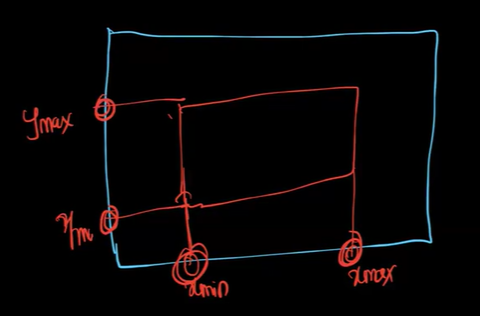
This above image is in format Pascal VOc format, we have to convert this into YOLO format.

- YOLO expects Xcenter,Ycenter, Width,Height
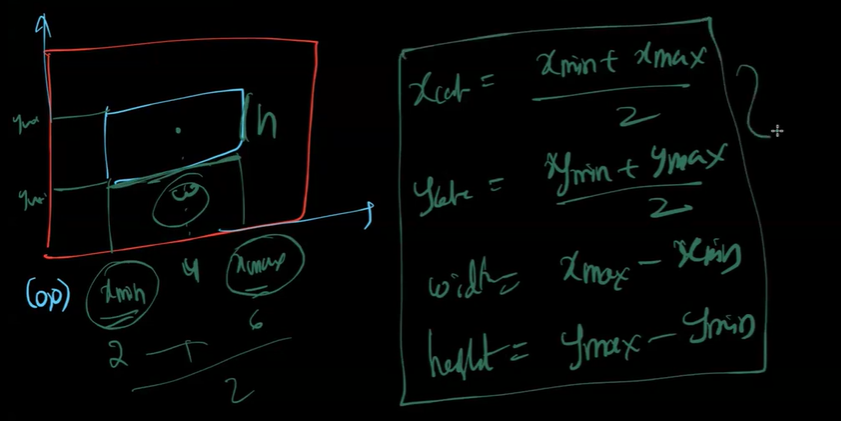

- YOLO expects the Input to be normalized, so we need to divide by pixels



In [3]:
# Imports
import os
import cv2
import shutil
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import xml.etree.ElementTree as xet
from sklearn.model_selection import train_test_split

import torch

print(f"{torch.cuda.is_available()= }")
print(f'{torch.cuda.device_count()= } ')

torch.cuda.is_available()= True
torch.cuda.device_count()= 2 


For using YOLO we have to install ultrlytics

In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00a 0:00:01


FOr visualizing whil training ipywidgets we need to install

In [5]:
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 3.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 8.1.5
    Uninstalling ipywidgets-8.1.5:
      Successfully uninstalled ipywidgets-8.1.5


In [6]:
dataset_path='/kaggle/input/datasets/andrewmvd/car-plate-detection'

Now we will write a function to extract numbers from a given string via regex
for eg file124.txt i want 124 extracted

In [7]:
import re

def num_in_string(filename):
    match=re.search(r'(\d+)',filename) # d+ for finding the digits consecutive
    if match:
        return int(match.group(0)) #match.group will return the number part from the match
        # int because for sorting purposes we need number format
    else:
        return 0
print(num_in_string('/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars339.xml'))
        

339


Now we have .xml files we have to read those files and convert into text

In [8]:
labels_dict=dict(
    img_path=[],
    xmin=[],
    xmax=[],
    ymin=[],
    ymax=[],
    img_w=[],
    img_h=[]
)

In [9]:
labels_dict

{'img_path': [],
 'xmin': [],
 'xmax': [],
 'ymin': [],
 'ymax': [],
 'img_w': [],
 'img_h': []}

In [10]:
# the glob library will help us read the xml files path in the text
# the * means here read all the files containing the .xml extension
xml_files=glob(f"{dataset_path}/annotations/*.xml")
xml_files

['/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars339.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars13.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars74.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars16.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars291.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars236.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars429.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars132.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars251.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars51.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars165.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars313.xml',
 '/kaggle/input/datasets/andrewm

Now here in the annotatinos folder i want to read the files in the sorted way

Now we will import the xml tree for parsing the xml data

In [11]:
import xml.etree.ElementTree as xet

In [12]:
# Process each XML file, sorted by the numerical value in the filename
for filename in sorted(xml_files,key=num_in_string):
    # Parse the XML file
    info=xet.parse(filename)
    root = info.getroot()
    # Find the 'object' element in the XML and extract bounding box information
    member_object = root.find('object')
    labels_info = member_object.find('bndbox')
    xmin = int(labels_info.find('xmin').text)
    xmax = int(labels_info.find('xmax').text)
    ymin = int(labels_info.find('ymin').text)
    ymax = int(labels_info.find('ymax').text)
    #print(xmin,xmax,ymin,ymax)
    
    # Get the image filename and construct the full path to the image
    img_name = root.find('filename').text
    img_path = os.path.join(dataset_path, 'images', img_name)
    #print(img_name,img_path)

    # Append the extracted information to the respective lists in the dictionary
    labels_dict['img_path'].append(img_path)
    labels_dict['xmin'].append(xmin)
    labels_dict['xmax'].append(xmax)
    labels_dict['ymin'].append(ymin)
    labels_dict['ymax'].append(ymax)

    # Read the image via cv2 to get its shape which will be the width and height of image
    # Shape will give me three dimensions rgb in which first two are height width
    height, width, _ = cv2.imread(img_path).shape
    labels_dict['img_w'].append(width)
    labels_dict['img_h'].append(height)
    #print(height,width)

    #print(labels_dict)
    #break
    

In [13]:
# Convert the dictionary to a pandas DataFrame
alldata = pd.DataFrame(labels_dict)

# Display the DataFrame
alldata

,img_path,xmin,xmax,ymin,ymax,img_w,img_h
0,/kaggle/input/datasets/andrewmvd/car-plate-det...,226,419,125,173,500,268
1,/kaggle/input/datasets/andrewmvd/car-plate-det...,134,262,128,160,400,248
2,/kaggle/input/datasets/andrewmvd/car-plate-det...,229,270,176,193,400,400
3,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,261,128,157,400,225
4,/kaggle/input/datasets/andrewmvd/car-plate-det...,156,503,82,253,590,350
...,...,...,...,...,...,...,...
428,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,258,128,157,400,225
429,/kaggle/input/datasets/andrewmvd/car-plate-det...,86,208,166,195,301,400
430,/kaggle/input/datasets/andrewmvd/car-plate-det...,38,116,159,197,400,225
431,/kaggle/input/datasets/andrewmvd/car-plate-det...,55,343,82,147,400,192


### So here we converted the XML info into Dataframe which is in good format for further calculations

### Now we will do the train test split

In [14]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
# Use 10% of the data for the test set
train, test = train_test_split(alldata, test_size=1/10, random_state=42)

# Split the training data further into training and validation sets
# Use 8/9 of the remaining data for the training set, resulting in an 80/10/10 split overall
train, val = train_test_split(train, train_size=8/9, random_state=42)

# Print the number of samples in each set
print(f'''
      len(train) = {len(train)}
      len(val) = {len(val)}
      len(test) = {len(test)}
''')



      len(train) = 345
      len(val) = 44
      len(test) = 44



In [15]:
train.head()

,img_path,xmin,xmax,ymin,ymax,img_w,img_h
124,/kaggle/input/datasets/andrewmvd/car-plate-det...,305,320,256,267,400,267
315,/kaggle/input/datasets/andrewmvd/car-plate-det...,12,385,98,181,400,300
282,/kaggle/input/datasets/andrewmvd/car-plate-det...,37,319,145,203,350,263
236,/kaggle/input/datasets/andrewmvd/car-plate-det...,223,250,106,119,400,176
112,/kaggle/input/datasets/andrewmvd/car-plate-det...,49,164,135,191,240,400


### Now we will have to convert this image into YOLO format and save it in text file.So YOLO expects the data in text format

#### The YOLO directory format we have to convert it into this format given below
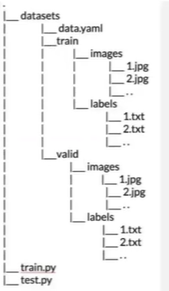

In [16]:
os.path.splitext(os.path.basename('/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars339.png'))

('Cars339', '.png')

In [17]:
def make_split_folder_in_yolo_format(split_name, split_df):
    """
    Creates a folder structure for a dataset split (train/val/test) in YOLO format.

    Parameters:
    split_name (str): The name of the split (e.g., 'train', 'val', 'test').
    split_df (pd.DataFrame): The DataFrame containing the data for the split.

    The function will create 'labels' and 'images' subdirectories under 'datasets/cars_license_plate/{split_name}',
    and save the corresponding labels and images in YOLO format.
    """
    labels_path = os.path.join('datasets', 'cars_license_plate_new', split_name, 'labels')
    images_path = os.path.join('datasets', 'cars_license_plate_new', split_name, 'images')
    # Here we have created path for two directories labels and images for the split_name it could be train , test, val insisde the dataset directory

    # Create directories for labels and images
    os.makedirs(labels_path)
    os.makedirs(images_path)
    
    # Iterate over each row in the DataFrame
    for _, row in split_df.iterrows():
        img_name, img_extension = os.path.splitext(os.path.basename(row['img_path']))
        
        # Calculate YOLO format bounding box coordinates divied by img_w and img_h for normalizing the values
        x_center = (row['xmin'] + row['xmax']) / 2 / row['img_w']
        y_center = (row['ymin'] + row['ymax']) / 2 / row['img_h']
        width = (row['xmax'] - row['xmin']) / row['img_w']
        height = (row['ymax'] - row['ymin']) / row['img_h']

        # Save the YOLO coordinates in the label in YOLO format
        label_path = os.path.join(labels_path, f'{img_name}.txt')
        with open(label_path, 'w') as file:
            file.write(f"0 {x_center:.4f} {y_center:.4f} {width:.4f} {height:.4f}\n")
            
        # Copy the image to the images directory
        shutil.copy(row['img_path'], os.path.join(images_path, img_name + img_extension))
    
    print(f"Created '{images_path}' and '{labels_path}'")

In [18]:
# Create YOLO format folders for train, validation, and test splits
make_split_folder_in_yolo_format("train", train)
make_split_folder_in_yolo_format("val", val)
make_split_folder_in_yolo_format("test", test)

Created 'datasets/cars_license_plate_new/train/images' and 'datasets/cars_license_plate_new/train/labels'
Created 'datasets/cars_license_plate_new/val/images' and 'datasets/cars_license_plate_new/val/labels'
Created 'datasets/cars_license_plate_new/test/images' and 'datasets/cars_license_plate_new/test/labels'


In [19]:
# Define the content of the datasets.yaml file
datasets_yaml = '''
path: cars_license_plate_new

train: train/images
val: val/images
test: test/images

# number of classes
nc: 1

# class names
names: ['license_plate']
'''

# Write the content to the datasets.yaml file
with open('datasets.yaml', 'w') as file:
    file.write(datasets_yaml)

### Now we will load the YOLO model

In [20]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
# Here since we have less data so we are using a nano version of yolo

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [21]:
model.train(
    data='datasets.yaml',  # Path to the dataset configuration file
    epochs=100,            # Number of training epochs
    batch=16,              # Batch size
    device='cuda',         # Use GPU for training
    imgsz=320,             # Image size (width and height) for training
    cache=True             # Cache images for faster training
)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f95dcb2cce0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

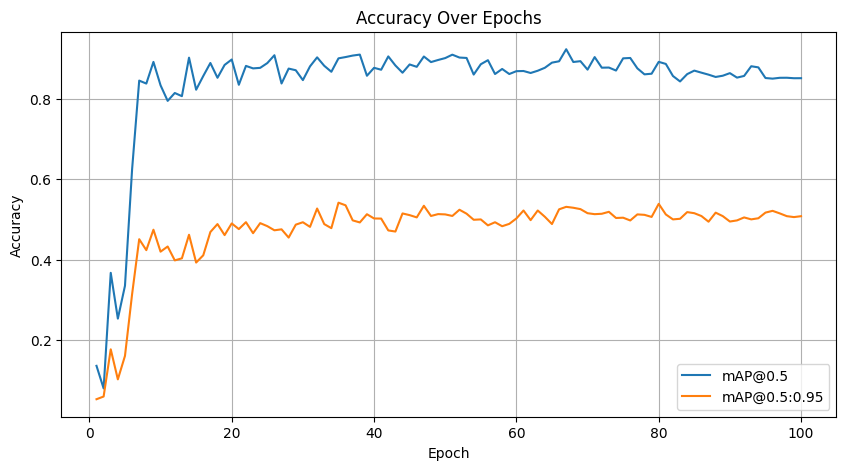

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob


# Find the most recent training log directory
log_dir = max(glob('runs/detect/train*'), key=num_in_string)

# Load the training results from the CSV file
results = pd.read_csv(os.path.join(log_dir, 'results.csv'))
results.columns = results.columns.str.strip()  # Remove any leading/trailing whitespace from column names

# Extract epochs and accuracy metrics
epochs = results.index + 1  # Epochs are zero-indexed, so add 1
mAP_0_5 = results['metrics/mAP50(B)']  # Mean Average Precision at IoU=0.5
mAP_0_5_0_95 = results['metrics/mAP50-95(B)']  # Mean Average Precision at IoU=0.5:0.95

# Plot the accuracy over epochs
plt.figure(figsize=(10, 5))
plt.plot(epochs, mAP_0_5, label='mAP@0.5')
plt.plot(epochs, mAP_0_5_0_95, label='mAP@0.5:0.95')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

### Saving the Model

In [23]:
# Save the trained model
model.save('best_license_plate_model.pt')

### Testing our model

### from the results directory (xyxy), we need to take the box coordinates and plot these box coordinates into image test

In [24]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


def predict_and_plot(path_test_car):
    """
    Predicts and plots the bounding boxes on the given test image using the trained YOLO model.

    Parameters:
    path_test_car (str): Path to the test image file.
    """
    # Perform prediction on the test image using the model
    results = model.predict(path_test_car, device='cpu')

    # Load the image using OpenCV
    image = cv2.imread(path_test_car)
    # Convert the image from BGR (OpenCV default) to RGB (matplotlib default)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Extract the bounding boxes and labels from the results
    for result in results:
        for box in result.boxes:
            # Get the coordinates of the bounding box
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            # Get the confidence score of the prediction
            confidence = box.conf[0]

            # Draw the bounding box on the image
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            # Draw the confidence score near the bounding box
            cv2.putText(image, f'{confidence*100:.2f}%', (x1, y1 - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    # Plot the image with bounding boxes
    plt.imshow(image)
    plt.axis('off')  # Hide the axis
    plt.show()  # Display the image


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars425.png: 160x320 1 license_plate, 49.0ms
Speed: 0.7ms preprocess, 49.0ms inference, 10.7ms postprocess per image at shape (1, 3, 160, 320)


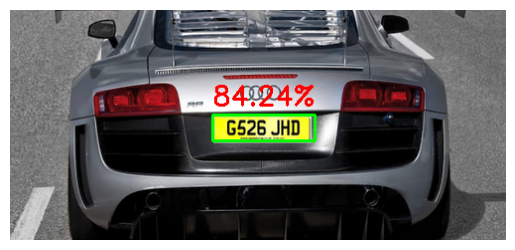

In [25]:
predict_and_plot(test.iloc[0].img_path)

# OCR Text Extraction from the Number Plate

### For OCR we have to install the library called pytesseract

### For the OCR we are cropping the Bounding Box according to predicted coordinates which whole processes is Region of Interest ROI and pass that ROI into OCR and it will extract the text

In [26]:
!pip3 install pytesseract

In [27]:
import pytesseract
from pytesseract import Output

In [28]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import pytesseract
from pytesseract import Output


def predict_and_plot(path_test_car):
    """
    Predicts and plots the bounding boxes on the given test image using the trained YOLO model.
    Also performs OCR on the detected bounding boxes to extract text.
    
    Parameters:
    path_test_car (str): Path to the test image file.
    """
    # Perform prediction on the test image using the model
    results = model.predict(path_test_car, device='cpu')

    # Load the image using OpenCV
    image = cv2.imread(path_test_car)
    # Convert the image from BGR (OpenCV default) to RGB (matplotlib default)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Extract the bounding boxes and labels from the results
    for result in results:
        for box in result.boxes:
            # Get the coordinates of the bounding box
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            # Get the confidence score of the prediction
            confidence = box.conf[0]

            # Draw the bounding box on the image
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            # Draw the confidence score near the bounding box
            cv2.putText(image, f'{confidence*100:.2f}%', (x1, y1 - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

            # Crop the bounding box from the image for OCR
            roi = image[y1:y2, x1:x2]

            # Perform OCR on the cropped image
            text = pytesseract.image_to_string(roi, config='--psm 6')
            print(f"Detected text: {text}")

    # Plot the image with bounding boxes
    plt.imshow(image)
    plt.axis('off')  # Hide the axis
    plt.show()  # Display the image


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars55.png: 256x320 1 license_plate, 64.8ms
Speed: 1.1ms preprocess, 64.8ms inference, 0.9ms postprocess per image at shape (1, 3, 256, 320)
Detected text: (9214



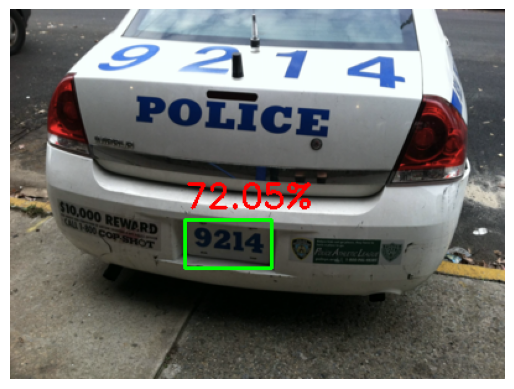

In [29]:
predict_and_plot(test.iloc[23].img_path)

# Vedio Numberplate Detection

### **Pipeline**


Read video → frame by frame
Convert frame (BGR → RGB)
Pass frame to YOLO model
Get bounding boxes + confidence
Draw boxes on frame
Save frame into output video

In [40]:
# Video license plate detection using the same logic as image detection
def predict_and_plot_video(video_path, output_path):
    """
    Predicts and saves bounding boxes on each video frame using the trained YOLO model.

    Parameters:
    video_path (str): Path to the test video file.
    output_path (str): Path to save the output video file.

    Returns:
    str: The path to the saved output video file.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error opening video file: {video_path}")
        return None
    
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 0:
        fps = 25
    #The above code block is to initialize the VideoWriter correctly so the output video maintains the same resolution and playback speed as the input video.
    
    output_dir = os.path.dirname(output_path)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, float(fps), (frame_width, frame_height))
    #FOURCC = Four Character Code It defines the video codec (compression format)
    # internally it becomes cv2.VideoWriter_fourcc('m', 'p', '4', 'v')
    #VideoWriter_fourcc defines the codec used to compress the video, and VideoWriter initializes the output video stream with specified path, FPS, and resolution so frames can be written sequentially.

    
    if not out.isOpened():
        print(f"Error creating output video file: {output_path}")
        cap.release()
        return None

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        #OpenCV reads images in BGR format But most deep learning models (like YOLO) expect RGB format
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = model.predict(rgb_frame, device="cpu", verbose=False)

        # Same logic as image prediction: iterate over detections and draw on current frame
        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0]) #This contains the bounding box coordinates predicted by YOLO xyxy is tensor shape 1,4 and [0] extract actual coordinates
                confidence = float(box.conf[0])

                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    frame,
                    f"{confidence * 100:.2f}%",
                    (x1, max(20, y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9,
                    (255, 0, 0),
                    2,
                )

        out.write(frame)

    cap.release()
    out.release()
    return output_path


from IPython.display import Video, display

# Example usage: update with your own input video path
input_video_path = "/kaggle/input/datasets/devdharmeshpatel/test-vedios/demo.mp4"
output_video_path = "/kaggle/working/result.mp4"

saved_video_path = predict_and_plot_video(input_video_path, output_video_path)
if saved_video_path:
    print("The output is saved in the path",saved_video_path)
else:
    print("Video processing failed. Check the input path and codecs.")

The output is saved in the path /kaggle/working/result.mp4
